# Analysis of the feature importance of the baseline models


Analyze the importance of the features in the baseline models to try to explain the models.
Use this information to improve the features of the models.

In [12]:
import core.constants as c
from core.processing import ResultsModel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load results from JSON and pickle files
with open(c.RICKD_BASELINE_RESULTS_SUMMARY_FILE, "r") as f:
    results_json = f.read()
results_model_loaded = ResultsModel.model_validate_json(results_json)

results_loaded = {}
trained_models_loaded = {}
for result in results_model_loaded.results:
    results_loaded[result.model_name] = {
        'test_accuracy': result.test_accuracy,
        'test_precision': result.test_precision,
        'test_recall': result.test_recall,
        'test_f1': result.test_f1,
        'test_roc_auc': result.test_roc_auc,
        'y_pred': np.array(result.y_pred),
        'y_pred_proba': np.array(result.y_pred_proba),
        'best_parameters': result.best_parameters,
        'best_score': result.best_score,
    }
    trained_models_loaded[result.model_name] = joblib.load(result.model_file)

results = results_loaded
trained_models = trained_models_loaded

In [3]:
# Load train and test sets from disk
X_train = pd.read_csv(c.RICKD_BASELINE_X_TRAIN_FILE, index_col=0)
X_test = pd.read_csv(c.RICKD_BASELINE_X_TEST_FILE, index_col=0)
y_train = pd.read_csv(c.RICKD_BASELINE_Y_TRAIN_FILE, index_col=0).squeeze()
y_test = pd.read_csv(c.RICKD_BASELINE_Y_TEST_FILE, index_col=0).squeeze()

In [13]:
def get_feature_importance(model_name, model, X_data, y_data):
    classifier = model.best_estimator_.named_steps['classifier']
    feature_names = X_data.columns
    
    if hasattr(classifier, 'feature_importances_'):
        # Tree-based models (Random Forest, XGBoost)
        importance_values = classifier.feature_importances_
        importance_type = 'Built-in'
        
    elif hasattr(classifier, 'coef_'):
        # Linear models (Logistic Regression) or SVM with linear kernel
        importance_values = np.abs(classifier.coef_[0])  # Use absolute values of coefficients
        importance_type = 'Coefficient Magnitude'
        
    else:
        # Models without built-in importance (SVM) - use permutation importance
        # TODO: Should we use a different approach: SHAP or LOFO?
        print(f"Computing permutation importance for {model_name}...")
        perm_importance = permutation_importance(
            model, X_data, y_data, 
            n_repeats=10, 
            random_state=RANDOM_STATE,
            scoring='roc_auc'
        )
        importance_values = perm_importance.importances_mean
        importance_type = 'Permutation'
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values,
        'importance_type': importance_type
    }).sort_values('importance', ascending=False)
    
    return importance_df

all_feature_importance = {}

for model_name, model in trained_models.items():
    print(f"Extracting feature importance for {model_name}...")
    importance_df = get_feature_importance(model_name, model, X_test, y_test)
    all_feature_importance[model_name] = importance_df

Extracting feature importance for Logistic Regression...
Extracting feature importance for Random Forest...
Extracting feature importance for XGBoost...
Extracting feature importance for SVM...
Computing permutation importance for SVM...


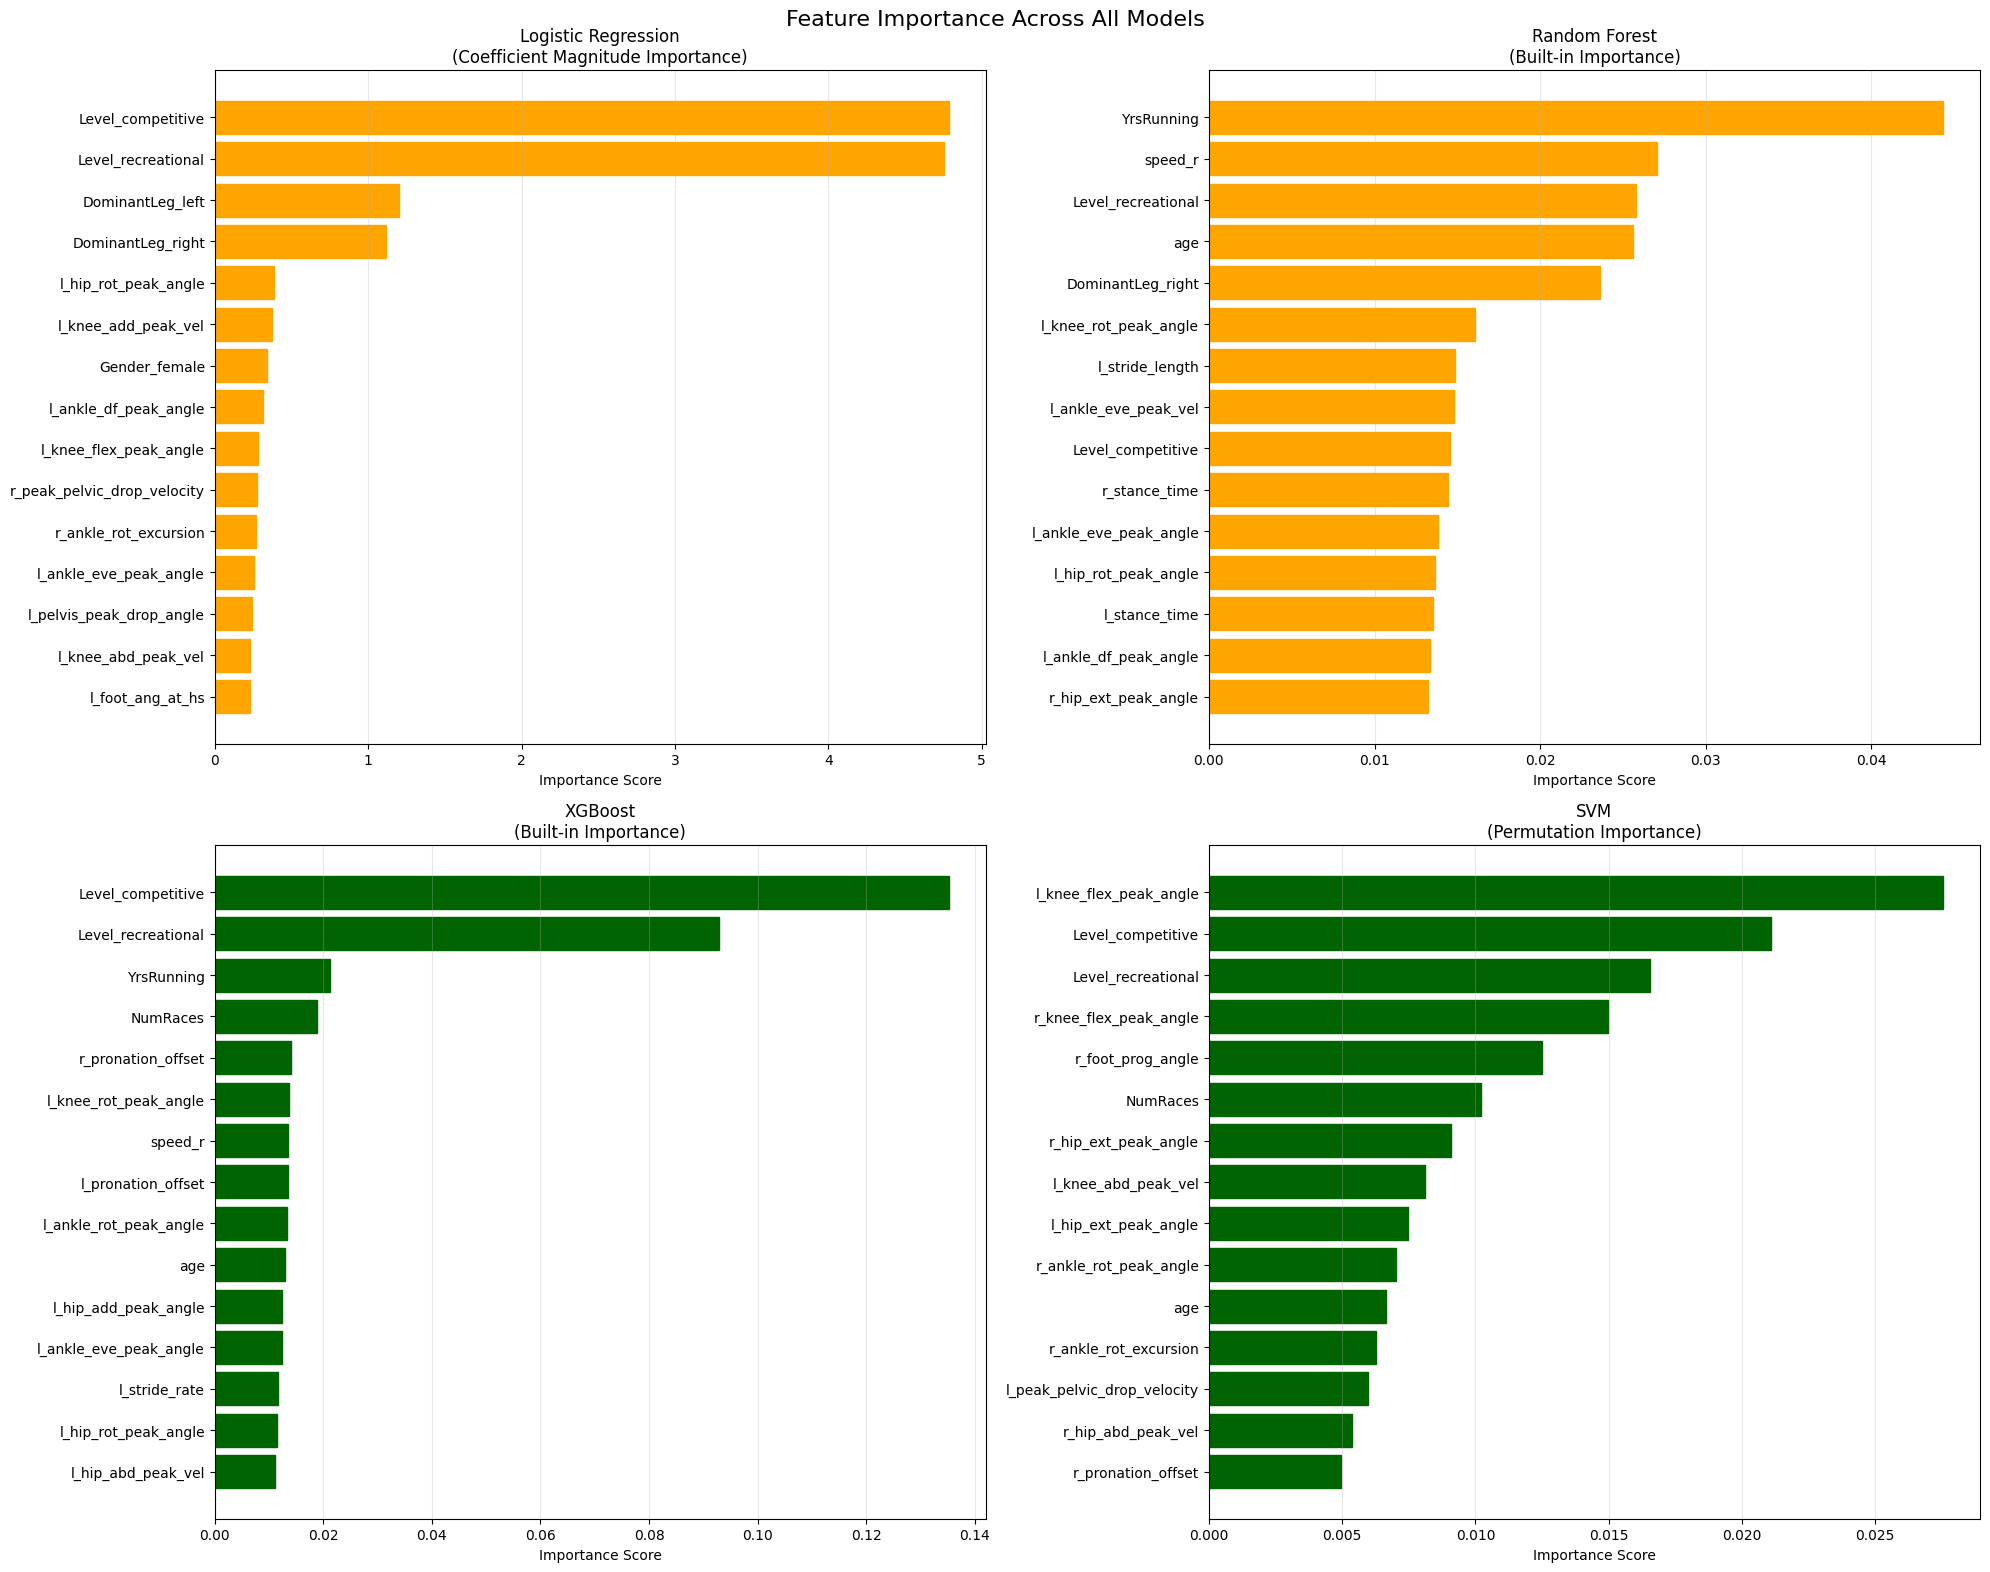


TOP 10 FEATURES COMPARISON ACROSS ALL MODELS

Logistic Regression (ROC-AUC: 0.7818):
--------------------------------------------------
 1. Level_competitive                   4.7869
 2. Level_recreational                  4.7568
 3. DominantLeg_left                    1.1990
 4. DominantLeg_right                   1.1175
 5. l_hip_rot_peak_angle                0.3885
 6. l_knee_add_peak_vel                 0.3742
 7. Gender_female                       0.3412
 8. l_ankle_df_peak_angle               0.3133
 9. l_knee_flex_peak_angle              0.2809
10. r_peak_pelvic_drop_velocity         0.2773

Random Forest (ROC-AUC: 0.7763):
--------------------------------------------------
 1. YrsRunning                          0.0444
 2. speed_r                             0.0270
 3. Level_recreational                  0.0258
 4. age                                 0.0256
 5. DominantLeg_right                   0.0236
 6. l_knee_rot_peak_angle               0.0161
 7. l_stride_length       

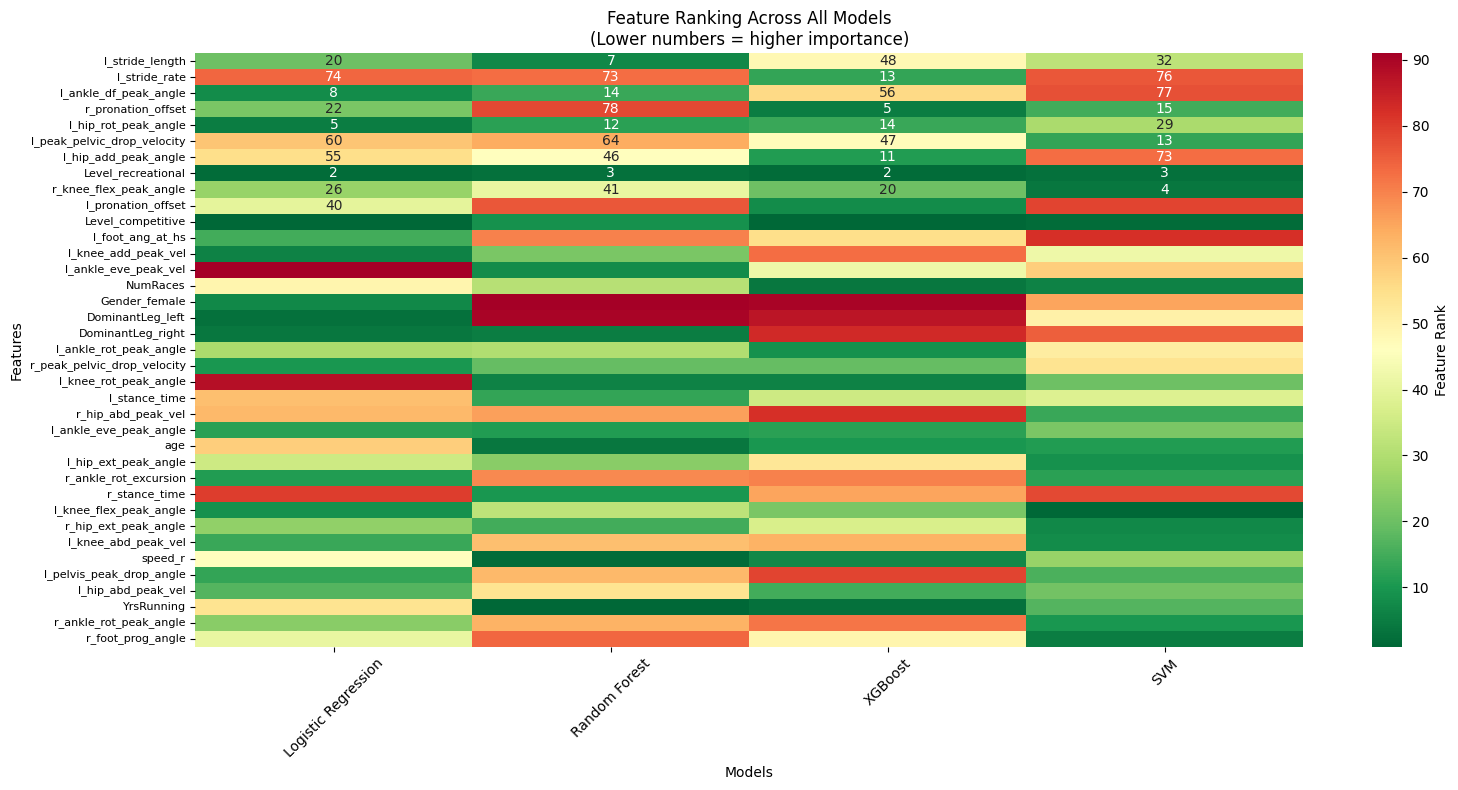


Heatmap shows ranking of 37 most important features across all models.
Lower numbers (green) indicate higher importance, higher numbers (red) indicate lower importance.


In [14]:
# Comprehensive Feature Importance Visualization and Analysis

# 1. Individual feature importance plots for each model
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

for idx, (model_name, importance_df) in enumerate(all_feature_importance.items()):
    ax = axes[idx]
    
    # Plot top 15 features for each model
    top_features = importance_df.head(15)
    bars = ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=10)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{model_name}\n({top_features["importance_type"].iloc[0]} Importance)', fontsize=12)
    ax.invert_yaxis()
    
    # Color bars based on performance
    model_auc = results[model_name]['test_roc_auc']
    if model_auc > 0.8:
        color = 'darkgreen'
    elif model_auc > 0.77:
        color = 'orange'
    else:
        color = 'lightcoral'
    
    for bar in bars:
        bar.set_color(color)
    
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Across All Models', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 2. Top features comparison across models
print("\n" + "="*80)
print("TOP 10 FEATURES COMPARISON ACROSS ALL MODELS")
print("="*80)

top_n = 10
for model_name, importance_df in all_feature_importance.items():
    print(f"\n{model_name} (ROC-AUC: {results[model_name]['test_roc_auc']:.4f}):")
    print("-" * 50)
    top_features = importance_df.head(top_n)
    for i, (_, row) in enumerate(top_features.iterrows()):
        print(f"{i+1:2d}. {row['feature']:35s} {row['importance']:.4f}")

# 3. Feature frequency analysis - how often features appear in top rankings
print(f"\n" + "="*80)
print("FEATURE FREQUENCY IN TOP RANKINGS ANALYSIS")
print("="*80)

# Count how often each feature appears in top N across all models
top_n_values = [5, 10, 15, 20]
feature_frequency = {}

for top_n in top_n_values:
    feature_count = {}
    
    for model_name, importance_df in all_feature_importance.items():
        top_features = importance_df.head(top_n)['feature'].tolist()
        for feature in top_features:
            feature_count[feature] = feature_count.get(feature, 0) + 1
    
    # Sort by frequency
    feature_frequency[top_n] = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\nFeatures appearing most frequently in Top {top_n}:")
    print("-" * 50)
    for feature, count in feature_frequency[top_n][:15]:  # Show top 15
        percentage = (count / len(trained_models)) * 100
        print(f"{feature:35s} {count}/4 models ({percentage:5.1f}%)")

# 4. Consensus features - features that appear in top rankings across multiple models
print(f"\n" + "="*80)
print("CONSENSUS IMPORTANT FEATURES")
print("="*80)

# Features that appear in top 10 of at least 3 models
consensus_features = []
for feature, count in feature_frequency[10]:
    if count >= 3:  # Appears in at least 3 out of 4 models
        consensus_features.append(feature)

print(f"\nFeatures in Top 10 of at least 3 models ({len(consensus_features)} features):")
print("-" * 50)
for feature in consensus_features:
    print(f"• {feature}")

# 5. Create a heatmap of feature rankings across models
print(f"\n" + "="*80)
print("FEATURE RANKING HEATMAP")
print("="*80)

# Get top 20 most frequently appearing features across all models
all_important_features = set()
for importance_df in all_feature_importance.values():
    all_important_features.update(importance_df.head(20)['feature'].tolist())

# Create ranking matrix
ranking_matrix = []
feature_list = list(all_important_features)

for model_name in trained_models.keys():
    model_rankings = []
    importance_df = all_feature_importance[model_name]
    feature_to_rank = {feature: idx + 1 for idx, feature in enumerate(importance_df['feature'])}
    
    for feature in feature_list:
        rank = feature_to_rank.get(feature, len(importance_df) + 1)  # If not in top, assign lowest rank
        model_rankings.append(rank)
    
    ranking_matrix.append(model_rankings)

# Create DataFrame for heatmap
ranking_df = pd.DataFrame(ranking_matrix, 
                         index=list(trained_models.keys()), 
                         columns=feature_list)

# Plot heatmap (show only features that appear in top 15 of at least one model)
frequently_important = []
for feature in feature_list:
    if any(ranking_df[feature] <= 15):
        frequently_important.append(feature)

plt.figure(figsize=(16, 8))
heatmap_data = ranking_df[frequently_important].T
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='d', 
            cmap='RdYlGn_r',  # Red = high rank (less important), Green = low rank (more important)
            cbar_kws={'label': 'Feature Rank'},
            xticklabels=True,
            yticklabels=True)
plt.title('Feature Ranking Across All Models\n(Lower numbers = higher importance)')
plt.xlabel('Models')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nHeatmap shows ranking of {len(frequently_important)} most important features across all models.")
print("Lower numbers (green) indicate higher importance, higher numbers (red) indicate lower importance.")



FEATURE IMPORTANCE STABILITY ANALYSIS

Most STABLE features across models (low coefficient of variation):
------------------------------------------------------------
 1. Level_recreational                  Mean Rank:   2.5, CV: 0.200
 2. l_foot_prog_angle                   Mean Rank:  32.2, CV: 0.284
 3. Height                              Mean Rank:  30.0, CV: 0.287
 4. l_ankle_eve_peak_angle              Mean Rank:  14.2, CV: 0.315
 5. l_ankle_eve_excursion               Mean Rank:  46.2, CV: 0.358
 6. l_peak_pelvic_drop_velocity         Mean Rank:  46.0, CV: 0.436
 7. l_stride_rate                       Mean Rank:  59.0, CV: 0.451
 8. r_swing_time                        Mean Rank:  59.8, CV: 0.452
 9. r_hip_abd_peak_vel                  Mean Rank:  56.0, CV: 0.453
10. l_foot_ang_at_hs                    Mean Rank:  55.5, CV: 0.455
11. l_stance_time                       Mean Rank:  36.8, CV: 0.463
12. l_hip_add_peak_angle                Mean Rank:  46.2, CV: 0.488
13. r_stance_tim

NameError: name 'X' is not defined

In [ ]:
# Detailed Feature Analysis and Insights

# 6. Feature importance stability across models
print("\n" + "="*80)
print("FEATURE IMPORTANCE STABILITY ANALYSIS")
print("="*80)

# Calculate coefficient of variation for top features across models
def calculate_feature_stability():
    """Calculate how stable feature rankings are across models"""
    stability_scores = {}
    
    # Get features that appear in top 20 of at least 2 models
    candidate_features = set()
    for importance_df in all_feature_importance.values():
        candidate_features.update(importance_df.head(20)['feature'].tolist())
    
    for feature in candidate_features:
        ranks = []
        for model_name, importance_df in all_feature_importance.items():
            feature_to_rank = {f: idx + 1 for idx, f in enumerate(importance_df['feature'])}
            rank = feature_to_rank.get(feature, len(importance_df) + 1)
            ranks.append(rank)
        
        # Calculate coefficient of variation (lower = more stable)
        if len(ranks) > 1:
            mean_rank = np.mean(ranks)
            std_rank = np.std(ranks)
            cv = std_rank / mean_rank if mean_rank > 0 else float('inf')
            stability_scores[feature] = {
                'mean_rank': mean_rank,
                'std_rank': std_rank,
                'cv': cv,
                'ranks': ranks
            }
    
    return stability_scores

stability_scores = calculate_feature_stability()

# Sort by stability (lowest coefficient of variation)
stable_features = sorted(stability_scores.items(), key=lambda x: x[1]['cv'])

print("\nMost STABLE features across models (low coefficient of variation):")
print("-" * 60)
for i, (feature, stats) in enumerate(stable_features[:15]):
    print(f"{i+1:2d}. {feature:35s} Mean Rank: {stats['mean_rank']:5.1f}, CV: {stats['cv']:.3f}")

print("\nMost UNSTABLE features across models (high coefficient of variation):")
print("-" * 60)
for i, (feature, stats) in enumerate(stable_features[-10:]):
    print(f"{i+1:2d}. {feature:35s} Mean Rank: {stats['mean_rank']:5.1f}, CV: {stats['cv']:.3f}")

# 7. Feature category analysis
print(f"\n" + "="*80)
print("FEATURE CATEGORY ANALYSIS")
print("="*80)

def categorize_features(feature_name):
    """Categorize features by body part and measurement type"""
    if 'age' in feature_name.lower() or 'height' in feature_name.lower() or 'weight' in feature_name.lower():
        return 'Demographics'
    elif 'speed' in feature_name.lower() or 'yrs' in feature_name.lower() or 'race' in feature_name.lower():
        return 'Experience/Performance'
    elif 'gender' in feature_name.lower():
        return 'Demographics'
    elif feature_name.startswith('l_'):
        body_part = 'Left ' + feature_name.split('_')[1].title()
        return body_part
    elif feature_name.startswith('r_'):
        body_part = 'Right ' + feature_name.split('_')[1].title()
        return body_part
    else:
        return 'Other'

# Categorize consensus features
consensus_categories = {}
for feature in consensus_features:
    category = categorize_features(feature)
    if category not in consensus_categories:
        consensus_categories[category] = []
    consensus_categories[category].append(feature)

print(f"\nConsensus features by body part/category:")
print("-" * 50)
for category, features in sorted(consensus_categories.items()):
    print(f"\n{category}:")
    for feature in features:
        print(f"  • {feature}")

# 8. Create summary statistics
print(f"\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

summary_stats = {
    'Total Features': pd.concat([X_train, X_test]).shape[1],
    'Models Analyzed': len(trained_models),
    'Consensus Features (Top 10, ≥3 models)': len(consensus_features),
    'Most Stable Feature': stable_features[0][0] if stable_features else 'N/A',
    'Best Performing Model': best_model_name,
    'Best Model ROC-AUC': results[best_model_name]['test_roc_auc']
}

for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"{key:35s}: {value:.4f}")
    else:
        print(f"{key:35s}: {value}")

# 9. Feature recommendations
print(f"\n" + "="*80)
print("FEATURE IMPORTANCE RECOMMENDATIONS")
print("="*80)

print("\n🎯 KEY FINDINGS:")
print("-" * 40)
print(f"1. {len(consensus_features)} features consistently important across models")
print(f"2. Most stable feature: {stable_features[0][0]}")
print(f"3. Best performing model: {best_model_name} (ROC-AUC: {results[best_model_name]['test_roc_auc']:.4f})")

print("\n📊 RECOMMENDED FEATURE SET:")
print("-" * 40)
print("For future model development, prioritize these consensus features:")
for i, feature in enumerate(consensus_features[:10], 1):
    print(f"{i:2d}. {feature}")

print(f"\n💡 INSIGHTS FOR MODEL IMPROVEMENT:")
print("-" * 40)
print("1. Focus on biomechanical features that show consensus across models")
print("2. Consider feature engineering based on stable, important features")
print("3. The high variability in some features suggests potential for ensemble methods")
print("4. Investigate why certain features are model-specific vs. universally important")
